# Alpaca Research Quickstart

Create a local `.env` from `.env.example`, add your Alpaca paper credentials, then run these cells.

In [1]:
from aic import AlpacaResearchClient

client = AlpacaResearchClient.from_env()

## Stock bars

In [2]:
stocks = client.stock_bars(["AAPL", "MSFT"], start="2025-01-01", timeframe="1Day")
stocks.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,AAPL,2025-01-02 05:00:00+00:00,248.930,249.025,241.845,243.820,1720928.0,19452.0,244.108677
1,AAPL,2025-01-03 05:00:00+00:00,243.315,244.165,241.890,243.410,1182159.0,12869.0,242.982652
2,AAPL,2025-01-06 05:00:00+00:00,244.310,247.330,243.880,245.025,970622.0,13645.0,245.353308
3,AAPL,2025-01-07 05:00:00+00:00,242.770,245.530,241.380,242.260,1048220.0,12788.0,243.360900
4,AAPL,2025-01-08 05:00:00+00:00,241.970,243.670,240.160,242.630,868980.0,12123.0,242.059482


In [3]:
stock_prices = stocks.pivot(index="timestamp", columns="symbol", values="close")
stock_returns = stock_prices.pct_change().dropna()
stock_returns.tail()

symbol,AAPL,MSFT
timestamp,,
2026-06-16 04:00:00+00:00,0.009206,-0.015198
2026-06-17 04:00:00+00:00,-0.010660,-0.037871
2026-06-18 04:00:00+00:00,0.006046,0.000079
2026-06-22 04:00:00+00:00,-0.003391,-0.031313
2026-06-23 04:00:00+00:00,-0.008658,0.018300


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Cumulative daily returns'}, xlabel='timestamp'>

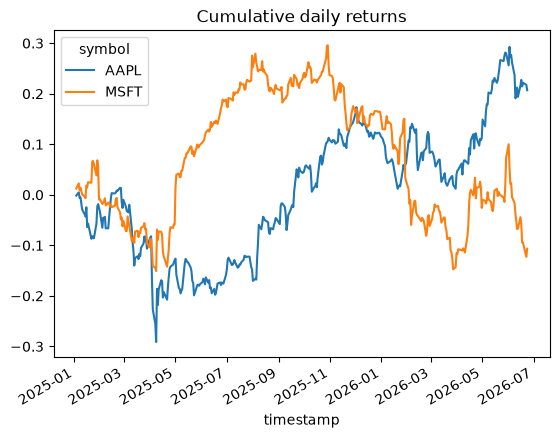

In [4]:
(1 + stock_returns).cumprod().sub(1).plot(title="Cumulative daily returns")

## Crypto bars

In [5]:
crypto = client.crypto_bars("BTC/USD", start="2025-01-01", timeframe="1Day")
crypto.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,BTC/USD,2025-01-01 00:00:00+00:00,93381.5825,94976.93600,92772.200000,94455.287,0.484563,106.0,94126.504821
1,BTC/USD,2025-01-02 00:00:00+00:00,94372.4310,97784.17075,94222.250000,96828.830,2.680558,275.0,96435.432279
2,BTC/USD,2025-01-03 00:00:00+00:00,96921.7555,98946.18650,96028.515000,98094.423,3.850016,271.0,97387.270972
3,BTC/USD,2025-01-04 00:00:00+00:00,98184.2500,98744.46200,97551.235000,98288.378,0.812107,146.0,98168.131295
4,BTC/USD,2025-01-05 00:00:00+00:00,98256.7000,98779.76550,97296.485732,98322.420,1.830606,129.0,98098.138552


## Account and positions

In [6]:
account = client.account()
account[["status", "buying_power", "cash", "portfolio_value"]]

,status,buying_power,cash,portfolio_value
0,ACTIVE,377328.28,87269.11,99845.4


In [7]:
positions = client.positions()
positions.head()

,asset_id,symbol,exchange,asset_class,asset_marginable,avg_entry_price,qty,side,market_value,cost_basis,...,unrealized_plpc,unrealized_intraday_pl,unrealized_intraday_plpc,current_price,lastday_price,change_today,swap_rate,avg_entry_swap_rate,usd,qty_available
0,b0b6dd9d-8b9b-48a9-ba46-b9d54906e415,AAPL,NASDAQ,us_equity,True,296.352929,31.381366885,long,9237.105343,9299.959992,...,-0.00676,-83.474436,-0.00896,294.35,297.01,-0.00896,None,None,None,31.381366885
1,f801f835-bfe6-4a9d-a6b1-ccbb84bfd75f,AMZN,NASDAQ,us_equity,True,240.31,0.1,long,23.339,24.031,...,-0.0288,0.06,0.00258,233.39,232.79,0.00258,None,None,None,0.1
2,798c7614-54a3-4512-8213-9aa1273e4e3e,BTC,ARCA,us_equity,True,28.417667,30,long,829.5,852.53001,...,-0.02701,-24.9,-0.02914,27.65,28.48,-0.02914,None,None,None,30
3,64bbff51-59d6-4b3c-9351-13ad85e3c752,BTCUSD,CRYPTO,crypto,False,64108.295882182,0.03971972,long,2486.343257,2546.363562,...,-0.02357,-59.21535,-0.02326,62597.2,64088.03,-0.02326,None,None,None,0.03971972
